<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    515 non-null    object 
 1   Average_Salary               515 non-null    int64  
 2   Years_Experience             515 non-null    int64  
 3   Education_Level              515 non-null    object 
 4   AI_Exposure_Index            515 non-null    float64
 5   Tech_Growth_Factor           515 non-null    float64
 6   Automation_Probability_2030  515 non-null    float64
 7   Risk_Category                515 non-null    object 
 8   Skill_1                      515 non-null    float64
 9   Skill_2                      515 non-null    float64
 10  Skill_3                      515 non-null    float64
 11  Skill_4                      515 non-null    float64
 12  Skill_5                      515 non-null    float64
 13  Skill_6             

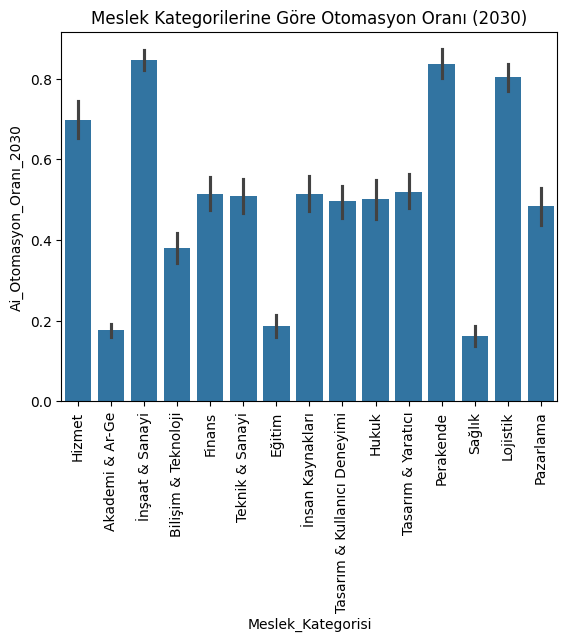

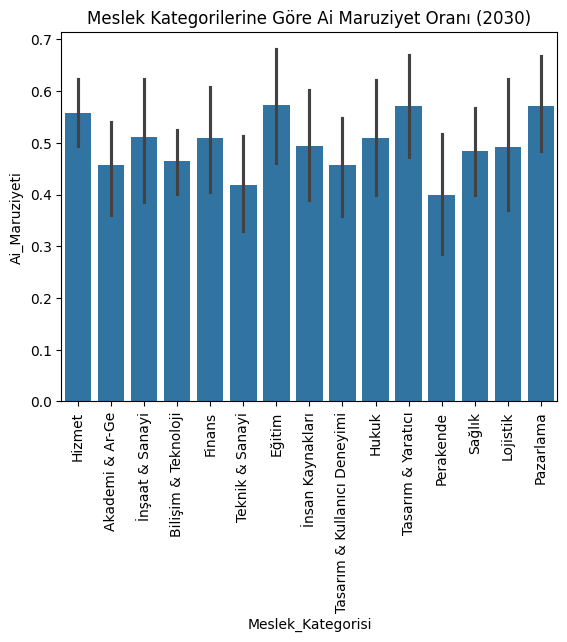

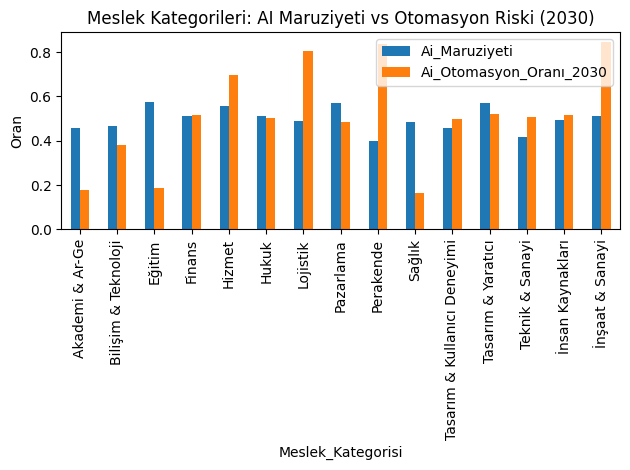

MAE: 0.08310760794915502
RMSE: 0.09945210221927633
R2: 0.8495186790057476


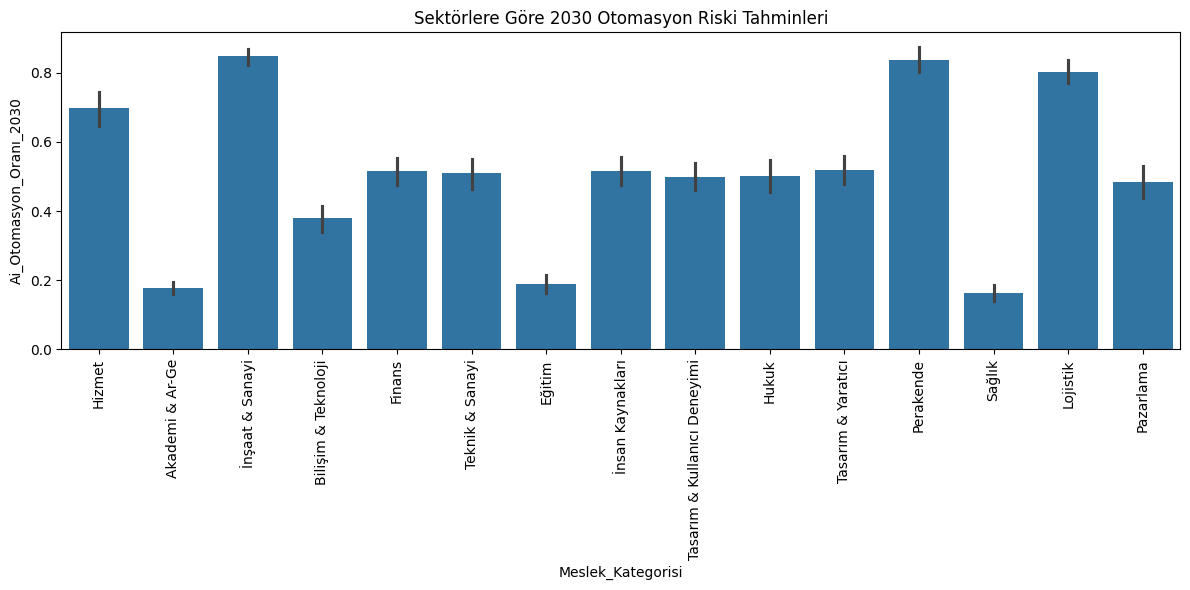

In [1]:
# -*- coding: utf-8 -*-
"""
Yusuf Baran YILDIZ
yusufbarany1@gmail.com




Bu çalışmada hangi mesleğin 2030 ne kadar risk altında olduğunu açıklar


Ai_Maruziyeti
Mesleğin yapay zekâ teknolojileriyle ne kadar iç içe olduğunu gösterir.
Düşük değer → AI ile az temas
Yüksek değer → AI ile yoğun temas
0–1 aralığında bir endekstir.

Teknolojik_Buyume
Mesleğin bağlı olduğu alanın teknolojik gelişme hızı.
Yüksek → hızla gelişen sektör
Düşük → daha yavaş dönüşen alan

Ai_Otomasyon_Orani_2030
Mesleğin 2030 yılına kadar otomasyon veya yapay zekâ tarafından yapılabilir olma ihtimali.
0’a yakın → otomasyon riski düşük
1’e yakın → otomasyon riski yüksek
Bu bir risk / olasılık göstergesidir, kesinlik değildir.

Risk_Category
Ai_Otomasyon_Orani_2030 değerine göre oluşturulmuş nitel risk sınıfı.
Low → düşük risk
Medium → orta risk
High → yüksek risk
Okunabilirliği artırmak için kullanılır.

Yetenek_skoru
Skill_1,Skill_10 değerlerinin toplamı.
Mesleğin gerektirdiği toplam beceri yoğunluğunu temsil eder.
Yüksek → daha karmaşık / çok beceri isteyen iş
Düşük → daha dar kapsamlı iş
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # numpy import edildi
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =============================================================================
# AŞAMA 1: İŞ ANLAYIŞI (BUSINESS UNDERSTANDING)
# Amaç: Yapay zekanın iş gücü üzerindeki etkisini kantitatif olarak analiz etmek.
# =============================================================================


# =============================================================================
# AŞAMA 2: VERİ ANLAYIŞI (DATA UNDERSTANDING)
# Amaç: Ham veriyi yüklemek ve verinin temel yapısını incelemek.
# =============================================================================

df= pd.read_csv("/content/aiRep")
df = df.head(515)
df.info()
df.describe()

# =============================================================================
# AŞAMA 3: VERİ HAZIRLAMA (DATA PREPARATION)
# Amaç: Veriyi temizlemek, yeni özellikler üretmek ve modele uygun hale getirmek ve
# verinin  anlaşılmasını  sağlamak için türkçeleştirmek
# =============================================================================

# Özellik Mühendisliği (Feature Engineering): Yetenek skoru hesaplama
# Yetenek_skoru: Skill_1–Skill_10 toplamıdır. Yüksek değer daha karmaşık işi temsil eder.
Yetenek_skoru = [f"Skill_{i}" for i in range(1, 11)]
df["Yetenek_skoru"] = df[Yetenek_skoru].sum(axis=1)
df.drop(columns=[f"Skill_{i}" for i in range(1, 11)],inplace=True)

# Sütun İsimlerini Türkçeleştirme
df.rename(columns={
    "Job_Title": "Meslek",
    "Average_Salary": "Maas",
    "Years_Experience": "Deneyim",
    "Education_Level":"Egitim_Seviyesi",
    "AI_Exposure_Index":"Ai_Maruziyeti",
    "Tech_Growth_Factor":"Teknolojik_Buyume",
    "Automation_Probability_2030":"Ai_Otomasyon_Oranı_2030"
}, inplace=True)

# Veri Etiketlerini Yerelleştirme
meslek_ceviri = {
    "Security Guard": "Güvenlik Görevlisi", "Research Scientist": "Araştırma Bilimcisi",
    "Construction Worker": "İnşaat İşçisi", "Software Engineer": "Yazılım Mühendisi",
    "Financial Analyst": "Finans Analisti", "AI Engineer": "Yapay Zekâ Mühendisi",
    "Mechanic": "Makine Teknisyeni", "Teacher": "Öğretmen",
    "HR Specialist": "İnsan Kaynakları Uzmanı", "Customer Support": "Müşteri Destek Temsilcisi",
    "UX Researcher": "UX Araştırmacısı", "Lawyer": "Avukat",
    "Data Scientist": "Veri Bilimcisi", "Graphic Designer": "Grafik Tasarımcı",
    "Retail Worker": "Perakende Çalışanı", "Doctor": "Doktor",
    "Truck Driver": "Kamyon Şoförü", "Chef": "Aşçı",
    "Nurse": "Hemşire", "Marketing Manager": "Pazarlama Müdürü"
}
df["Meslek"] = df["Meslek"].replace(meslek_ceviri)

egitim_sev = {"High School": "Lise", "Bachelor's": "Lisans", "Master's": "Yüksek Lisans", "PhD": "Doktora"}
df["Egitim_Seviyesi"] = df["Egitim_Seviyesi"].replace(egitim_sev)

# Sektörel Gruplandırma
meslek_kategori = {
    "Güvenlik Görevlisi": "Hizmet", "Araştırma Bilimcisi": "Akademi & Ar-Ge",
    "İnşaat İşçisi": "İnşaat & Sanayi", "Yazılım Mühendisi": "Bilişim & Teknoloji",
    "Finans Analisti": "Finans", "Yapay Zekâ Mühendisi": "Bilişim & Teknoloji",
    "Makine Teknisyeni": "Teknik & Sanayi", "Öğretmen": "Eğitim",
    "İnsan Kaynakları Uzmanı": "İnsan Kaynakları", "Müşteri Destek Temsilcisi": "Hizmet",
    "UX Araştırmacısı": "Tasarım & Kullanıcı Deneyimi", "Avukat": "Hukuk",
    "Veri Bilimcisi": "Bilişim & Teknoloji", "Grafik Tasarımcı": "Tasarım & Yaratıcı",
    "Perakende Çalışanı": "Perakende", "Doktor": "Sağlık",
    "Kamyon Şoförü": "Lojistik", "Aşçı": "Hizmet",
    "Hemşire": "Sağlık", "Pazarlama Müdürü": "Pazarlama"
}
df["Meslek_Kategorisi"] = df["Meslek"].map(meslek_kategori)

# Sütun Sıralamasını Düzenleme
cols = df.columns.tolist()
cols.remove("Meslek_Kategorisi")
meslek_index = cols.index("Meslek")
cols.insert(meslek_index + 1, "Meslek_Kategorisi")
df = df[cols]

# Keşifçi Veri Analizi (EDA) Görselleştirmeleri
# 1. Kategori bazlı otomasyon riski
kategori_oto = df.groupby("Meslek_Kategorisi")["Ai_Otomasyon_Oranı_2030"].mean()
plt.figure()
sns.barplot(x="Meslek_Kategorisi", y="Ai_Otomasyon_Oranı_2030", data=df, estimator="mean")
plt.xticks(rotation=90)
plt.title("Meslek Kategorilerine Göre Otomasyon Oranı (2030)")
plt.show()

# 2. AI Maruziyeti analizi
kategori_maruziyet=df.groupby("Meslek_Kategorisi")["Ai_Maruziyeti"].mean()
plt.figure()
sns.barplot(x="Meslek_Kategorisi", y="Ai_Maruziyeti", data=df, estimator="mean")
plt.xticks(rotation=90)
plt.title("Meslek Kategorilerine Göre Ai Maruziyet Oranı (2030)")
plt.show()

# 3. Maruziyet vs Otomasyon Karşılaştırması
kategori_ozet = df.groupby("Meslek_Kategorisi")[["Ai_Maruziyeti", "Ai_Otomasyon_Oranı_2030"]].mean().reset_index()
kategori_ozet.plot(x="Meslek_Kategorisi", kind="bar", rot=90)
plt.title("Meslek Kategorileri: AI Maruziyeti vs Otomasyon Riski (2030)")
plt.ylabel("Oran")
plt.tight_layout()
plt.show()

# =============================================================================
# AŞAMA 4: MODELLEME (MODELING)
# Amaç: Makine öğrenmesi algoritmasını seçmek ve eğitmek.
# =============================================================================


X = df.drop("Ai_Otomasyon_Oranı_2030", axis=1)
y = df["Ai_Otomasyon_Oranı_2030"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# Pipeline Ön İşleme: Ölçeklendirme ve One-Hot Encoding
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

# =============================================================================
# AŞAMA 5: DEĞERLENDİRME (EVALUATION)
# Amaaç: Modelin başarısını test verisi üzerinden metriklerle ölçmek.
# =============================================================================

y_pred = lr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
# RMSE hesaplamasını düzeltme
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))
#MAE: 0.08310765909870658
#RMSE: 0.09945212802678642
#R2: 0.8495186009068714
# =============================================================================
# AŞAMA 6: DAĞITIM (DEPLOYMENT)
# Sektörel bazda risk analizi grafiği
plt.figure(figsize=(12,6))
sns.barplot(x="Meslek_Kategorisi", y="Ai_Otomasyon_Oranı_2030", data=df, estimator="mean")
plt.xticks(rotation=90)
plt.title("Sektörlere Göre 2030 Otomasyon Riski Tahminleri")
plt.tight_layout()
plt.show()